## Exploratory Data Analysis

### EDA 1 — Dataset Overview and Data Quality

The dataset is first inspected to understand its size, feature structure, data types, missing values, duplicate records and the number of unique values in each attribute. This provides the basis for subsequent preprocessing and class-distribution analysis.

In [23]:
# ============================================
# CELL 1 - Imports and project paths
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "FashionDataset"

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_CSV = TRAIN_DIR / "styles_train.csv"
PREDICTION_CSV = TEST_DIR / "styles_prediction.csv"

TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"
TEST_IMAGE_DIR = TEST_DIR / "images_test"

print("Project directory:", PROJECT_DIR)

Project directory: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/VS code/MachineLearning/COSC2753_A2


In [24]:
# ============================================
# CELL 2 - Check dataset paths
# ============================================

print("Train CSV exists:", TRAIN_CSV.exists())
print("Prediction CSV exists:", PREDICTION_CSV.exists())
print("Train image folder exists:", TRAIN_IMAGE_DIR.exists())
print("Test image folder exists:", TEST_IMAGE_DIR.exists())

assert TRAIN_CSV.exists(), f"Cannot find {TRAIN_CSV}"
assert PREDICTION_CSV.exists(), f"Cannot find {PREDICTION_CSV}"
assert TRAIN_IMAGE_DIR.exists(), f"Cannot find {TRAIN_IMAGE_DIR}"
assert TEST_IMAGE_DIR.exists(), f"Cannot find {TEST_IMAGE_DIR}"

print("\nAll dataset paths found successfully.")

Train CSV exists: True
Prediction CSV exists: True
Train image folder exists: True
Test image folder exists: True

All dataset paths found successfully.


In [25]:
# ============================================
# CELL 3 - Load metadata
# ============================================

train = pd.read_csv(TRAIN_CSV)
prediction = pd.read_csv(PREDICTION_CSV)

print("Training dataset shape:", train.shape)
print("Prediction dataset shape:", prediction.shape)

display(train.head())
display(prediction.head())

Training dataset shape: (38617, 12)
Prediction dataset shape: (5829, 5)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,NaN,NaN
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,NaN,NaN


,id,gender,articleType,season,usage
0,52003,NaN,NaN,NaN,NaN
1,52007,NaN,NaN,NaN,NaN
2,52017,NaN,NaN,NaN,NaN
3,52021,NaN,NaN,NaN,NaN
4,52023,NaN,NaN,NaN,NaN


In [26]:
# ============================================
# CELL 4 - Inspect dataset columns
# ============================================

print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nPREDICTION COLUMNS")
print(prediction.columns.tolist())

TRAIN COLUMNS
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']

PREDICTION COLUMNS
['id', 'gender', 'articleType', 'season', 'usage']


In [27]:
# ============================================
# CELL 5 - Basic dataset information
# ============================================

print("=" * 60)
print("TRAINING DATASET")
print("=" * 60)

print("Rows:", len(train))
print("Columns:", len(train.columns))

print("\nData types:")
display(train.dtypes.to_frame("Data Type"))

print("\nMissing values:")
missing_values = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_values[
        missing_values > 0
    ].to_frame("Missing Count")
)

TRAINING DATASET
Rows: 38617
Columns: 12

Data types:


,Data Type
id,int64
gender,str
masterCategory,str
subCategory,str
articleType,str
baseColour,str
season,str
year,int64
usage,str
productDisplayName,str



Missing values:


,Missing Count
Unnamed: 11,38615
Unnamed: 10,38596
usage,72
season,20
baseColour,14
productDisplayName,7


In [28]:
# ============================================
# CELL 6 - Inspect assignment targets
# ============================================

target_columns = [
    "articleType",
    "season",
    "gender",
    "usage"
]

for column in target_columns:

    print("\n" + "=" * 60)
    print(column.upper())
    print("=" * 60)

    print(
        "Number of classes:",
        train[column].nunique(dropna=True)
    )

    print(
        "Missing values:",
        train[column].isna().sum()
    )

    display(
        train[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


ARTICLETYPE
Number of classes: 125
Missing values: 0


,Count
articleType,
Tshirts,6781
Shirts,3089
Casual Shoes,2683
Watches,2252
Sports Shoes,1991
...,...
Ties and Cufflinks,1
Cushion Covers,1
Body Wash and Scrub,1



SEASON
Number of classes: 4
Missing values: 20


,Count
season,
Summer,19137
Fall,10512
Winter,7381
Spring,1567
NaN,20



GENDER
Number of classes: 5
Missing values: 0


,Count
gender,
Men,20918
Women,14160
Unisex,2080
Boys,814
Girls,645



USAGE
Number of classes: 8
Missing values: 72


,Count
usage,
Casual,29641
Sports,3940
Ethnic,2570
Formal,2300
NaN,72
Smart Casual,55
Travel,25
Party,13
Home,1


In [29]:
# ============================================
# CELL 7 - Target class imbalance
# ============================================

target_columns = ["articleType", "season", "gender", "usage"]

for target in target_columns:
    counts = train[target].value_counts(dropna=True)
    percentages = train[target].value_counts(normalize=True, dropna=True) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print("\n" + "=" * 60)
    print(target.upper())
    print("=" * 60)
    display(summary.head(15))

    print("Largest class percentage:", round(percentages.iloc[0], 2), "%")
    print("Smallest class count:", counts.iloc[-1])


ARTICLETYPE


,Count,Percentage
articleType,,
Tshirts,6781,17.56
Shirts,3089,8.00
Casual Shoes,2683,6.95
Watches,2252,5.83
Sports Shoes,1991,5.16
Tops,1614,4.18
Kurtas,1556,4.03
Handbags,1439,3.73
Heels,1048,2.71


Largest class percentage: 17.56 %
Smallest class count: 1

SEASON


,Count,Percentage
season,,
Summer,19137,49.58
Fall,10512,27.24
Winter,7381,19.12
Spring,1567,4.06


Largest class percentage: 49.58 %
Smallest class count: 1567

GENDER


,Count,Percentage
gender,,
Men,20918,54.17
Women,14160,36.67
Unisex,2080,5.39
Boys,814,2.11
Girls,645,1.67


Largest class percentage: 54.17 %
Smallest class count: 645

USAGE


,Count,Percentage
usage,,
Casual,29641,76.90
Sports,3940,10.22
Ethnic,2570,6.67
Formal,2300,5.97
Smart Casual,55,0.14
Travel,25,0.06
Party,13,0.03
Home,1,0.00


Largest class percentage: 76.9 %
Smallest class count: 1


## EDA 2 — Image Data Inspection

The image dataset is inspected to verify file availability, consistency between metadata IDs and image files, and the general visual characteristics of the fashion images before defining the image preprocessing pipeline.

In [30]:
# ============================================
# CELL 8 - Match metadata IDs with image files
# ============================================

train_image_files = list(TRAIN_IMAGE_DIR.glob("*"))
test_image_files = list(TEST_IMAGE_DIR.glob("*"))

print("Training image files:", len(train_image_files))
print("Test image files:", len(test_image_files))

train_image_ids = {p.stem for p in train_image_files}
test_image_ids = {p.stem for p in test_image_files}

train_ids = set(train["id"].astype(str))
test_ids = set(prediction["id"].astype(str))

print("\nTrain IDs with image:", len(train_ids & train_image_ids))
print("Train IDs without image:", len(train_ids - train_image_ids))

print("\nTest IDs with image:", len(test_ids & test_image_ids))
print("Test IDs without image:", len(test_ids - test_image_ids))

Training image files: 38613
Test image files: 5829

Train IDs with image: 38612
Train IDs without image: 5

Test IDs with image: 5829
Test IDs without image: 0


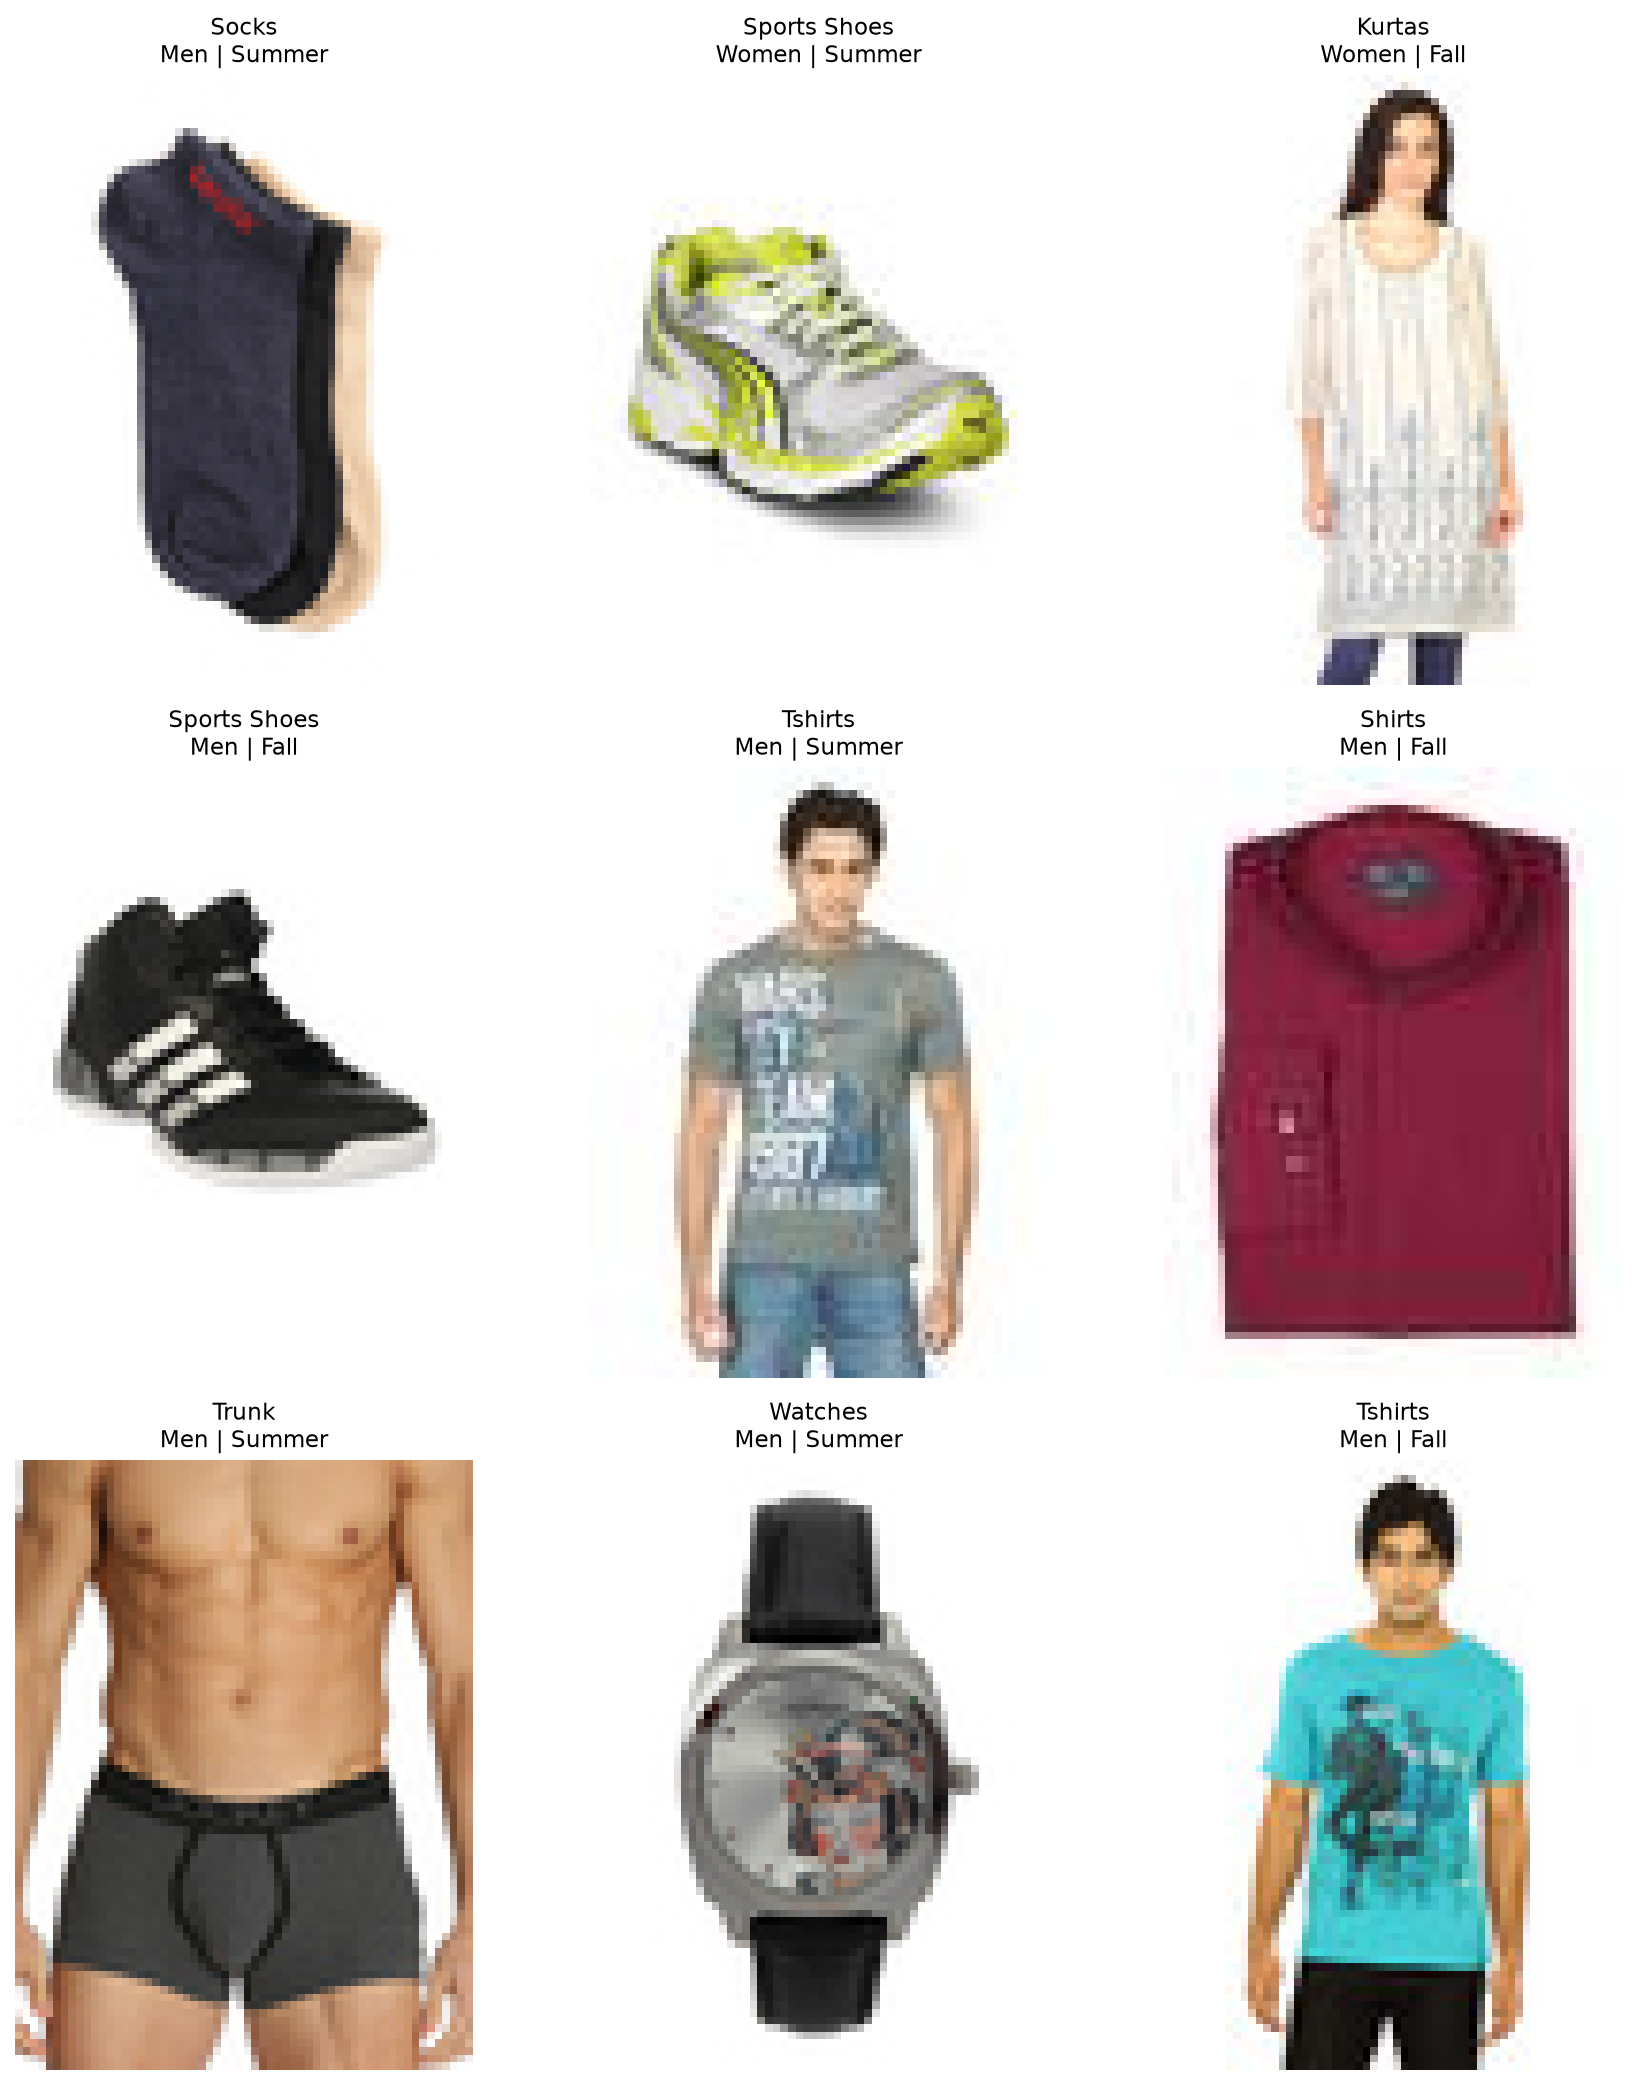

In [31]:
# ============================================
# CELL 9 - Visual inspection of training images
# ============================================

from PIL import Image

sample_rows = train.sample(
    9,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 14),
    dpi=150
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_rows.iterrows()
):
    image_path = (
        TRAIN_IMAGE_DIR /
        f"{row['id']}.jpg"
    )

    if image_path.exists():
        image = (
            Image.open(image_path)
            .convert("RGB")
        )

        ax.imshow(
            image,
            interpolation="nearest"
        )

        ax.set_title(
            f"{row['articleType']}\n"
            f"{row['gender']} | {row['season']}",
            fontsize=11
        )

    else:
        ax.set_title(
            f"Image missing: {row['id']}"
        )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# CELL 10 - Image availability summary
# ============================================

print("=" * 60)
print("IMAGE AVAILABILITY SUMMARY")
print("=" * 60)

print(
    "Training metadata rows:",
    len(train)
)

print(
    "Training image files:",
    len(train_image_files)
)

print(
    "Training IDs with images:",
    len(train_ids & train_image_ids)
)

print(
    "Training IDs without images:",
    len(train_ids - train_image_ids)
)

print()

print(
    "Test metadata rows:",
    len(prediction)
)

print(
    "Test image files:",
    len(test_image_files)
)

print(
    "Test IDs with images:",
    len(test_ids & test_image_ids)
)

print(
    "Test IDs without images:",
    len(test_ids - test_image_ids)
)

IMAGE AVAILABILITY SUMMARY
Training metadata rows: 38617
Training image files: 38613
Training IDs with images: 38612
Training IDs without images: 5

Test metadata rows: 5829
Test image files: 5829
Test IDs with images: 5829
Test IDs without images: 0


## EDA 3 — Image Dimensions and Quality Checks

Training images are inspected to understand image dimensions, colour modes, and possible corrupted files. These checks help define a consistent preprocessing strategy before model training.

In [33]:
# ============================================
# CELL 11 - Inspect image dimensions and modes
# ============================================

from collections import Counter
from PIL import Image

sample_image_paths = train_image_files[:1000]

image_sizes = []
image_modes = []
failed_images = []

for image_path in sample_image_paths:
    try:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)
            image_modes.append(img.mode)
    except Exception as error:
        failed_images.append((image_path.name, str(error)))

print("Images inspected:", len(sample_image_paths))

print("\nMost common image sizes:")
display(
    pd.DataFrame(
        Counter(image_sizes).most_common(10),
        columns=["ImageSize", "Count"]
    )
)

print("\nImage colour modes:")
display(
    pd.DataFrame(
        Counter(image_modes).items(),
        columns=["Mode", "Count"]
    )
)

print("\nFailed images:", len(failed_images))

Images inspected: 1000

Most common image sizes:


,ImageSize,Count
0,"(60, 80)",1000



Image colour modes:


,Mode,Count
0,RGB,994
1,L,6



Failed images: 0


In [34]:
# ============================================
# CELL 12 - Image dimension summary
# ============================================

image_dimension_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

display(
    image_dimension_df.describe()
)

print(
    "Unique image sizes:",
    image_dimension_df.drop_duplicates().shape[0]
)

,Width,Height
count,1000.0,1000.0
mean,60.0,80.0
std,0.0,0.0
min,60.0,80.0
25%,60.0,80.0
50%,60.0,80.0
75%,60.0,80.0
max,60.0,80.0


Unique image sizes: 1


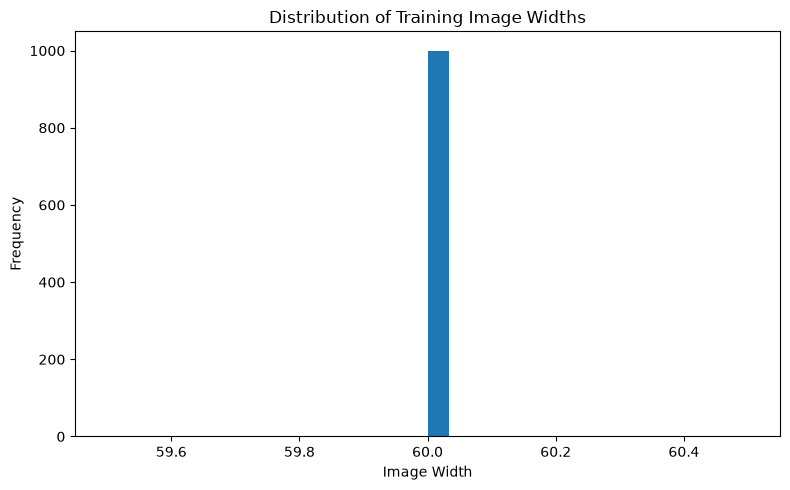

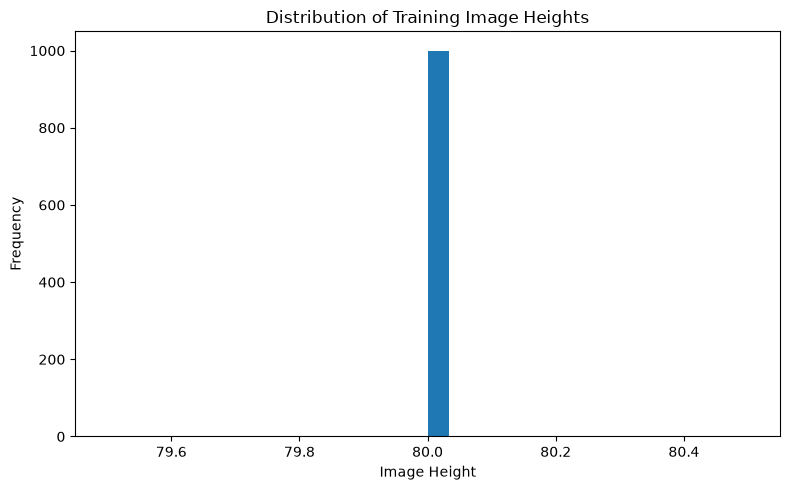

In [35]:
# ============================================
# CELL 13 - Image dimension distributions
# ============================================

plt.figure(figsize=(8, 5))
plt.hist(
    image_dimension_df["Width"],
    bins=30
)
plt.xlabel("Image Width")
plt.ylabel("Frequency")
plt.title("Distribution of Training Image Widths")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(
    image_dimension_df["Height"],
    bins=30
)
plt.xlabel("Image Height")
plt.ylabel("Frequency")
plt.title("Distribution of Training Image Heights")
plt.tight_layout()
plt.show()

In [36]:
# ============================================
# CELL 14 - Check corrupted training images
# ============================================

corrupted_train_images = []

for image_path in train_image_files:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception as error:
        corrupted_train_images.append(
            {
                "File": image_path.name,
                "Error": str(error)
            }
        )

print(
    "Corrupted training images:",
    len(corrupted_train_images)
)

if corrupted_train_images:
    display(
        pd.DataFrame(corrupted_train_images)
    )

Corrupted training images: 1


,File,Error
0,.DS_Store,cannot identify image file '/Users/_thu_thuu/D...


 ## EDA 4 — Label Quality and Rare Classes

The target variables are inspected for missing labels and extremely rare classes. These issues are important because each prediction task requires a different target-specific training subset and stratified validation strategy.

In [37]:
# ============================================
# CELL 15 - Missing labels and rare classes
# ============================================

target_columns = [
    "articleType",
    "season",
    "gender",
    "usage"
]

rare_class_summary = []

for target in target_columns:
    counts = train[target].value_counts(dropna=True)

    rare_classes_1 = counts[counts == 1]
    rare_classes_5 = counts[counts <= 5]
    rare_classes_10 = counts[counts <= 10]

    rare_class_summary.append({
        "Target": target,
        "Classes": len(counts),
        "MissingLabels": train[target].isna().sum(),
        "ClassesWith1Sample": len(rare_classes_1),
        "ClassesWith5OrFewer": len(rare_classes_5),
        "ClassesWith10OrFewer": len(rare_classes_10)
    })

rare_class_summary = pd.DataFrame(rare_class_summary)

display(rare_class_summary)

,Target,Classes,MissingLabels,ClassesWith1Sample,ClassesWith5OrFewer,ClassesWith10OrFewer
0,articleType,125,0,7,24,33
1,season,4,20,0,0,0
2,gender,5,0,0,0,0
3,usage,8,72,1,1,1


## Shared Data Preprocessing

Only records with available image files are retained for image-based modelling. Image paths are then created for both training and unseen test observations. Target-specific missing labels are not removed here because each prediction task will construct its own modelling subset.


In [38]:
# ============================================
# CELL 16 - Create cleaned training metadata
# ============================================

valid_extensions = {".jpg", ".jpeg", ".png"}

valid_train_image_ids = {
    path.stem
    for path in TRAIN_IMAGE_DIR.iterdir()
    if path.suffix.lower() in valid_extensions
}

clean_train = train[
    train["id"].astype(str).isin(valid_train_image_ids)
].copy()

print("Original training rows:", len(train))
print("Rows with available images:", len(clean_train))
print(
    "Rows removed because image is missing:",
    len(train) - len(clean_train)
)

assert len(clean_train) == 38612

Original training rows: 38617
Rows with available images: 38612
Rows removed because image is missing: 5


In [39]:
# ============================================
# CELL 17 - Add image paths
# ============================================

clean_train["image_path"] = clean_train["id"].apply(
    lambda image_id:
    str(TRAIN_IMAGE_DIR / f"{image_id}.jpg")
)

prediction["image_path"] = prediction["id"].apply(
    lambda image_id:
    str(TEST_IMAGE_DIR / f"{image_id}.jpg")
)

train_paths_valid = clean_train[
    "image_path"
].apply(
    lambda path: Path(path).exists()
).sum()

test_paths_valid = prediction[
    "image_path"
].apply(
    lambda path: Path(path).exists()
).sum()

print(
    "Valid training image paths:",
    train_paths_valid,
    "/",
    len(clean_train)
)

print(
    "Valid test image paths:",
    test_paths_valid,
    "/",
    len(prediction)
)

assert train_paths_valid == len(clean_train)
assert test_paths_valid == len(prediction)

Valid training image paths: 38612 / 38612
Valid test image paths: 5829 / 5829


In [40]:
# ============================================
# CELL 18 - Shared image preprocessing settings
# ============================================

IMAGE_WIDTH = 60
IMAGE_HEIGHT = 80
IMAGE_CHANNELS = 3

IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

NORMALISATION_SCALE = 255.0

print("Image width:", IMAGE_WIDTH)
print("Image height:", IMAGE_HEIGHT)
print("Image channels:", IMAGE_CHANNELS)
print("Preprocessing:")
print("- Convert all images to RGB")
print("- Preserve native 60 x 80 resolution")
print("- Normalise pixel values from [0, 255] to [0, 1]")

Image width: 60
Image height: 80
Image channels: 3
Preprocessing:
- Convert all images to RGB
- Preserve native 60 x 80 resolution
- Normalise pixel values from [0, 255] to [0, 1]


In [41]:
# ============================================
# CELL 19 - Export shared processed metadata
# ============================================

PROCESSED_DIR = PROJECT_DIR / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

clean_train_path = (
    PROCESSED_DIR /
    "clean_train_metadata.csv"
)

prediction_metadata_path = (
    PROCESSED_DIR /
    "prediction_metadata.csv"
)

clean_train.to_csv(
    clean_train_path,
    index=False
)

prediction.to_csv(
    prediction_metadata_path,
    index=False
)

print("Saved:", clean_train_path)
print("Saved:", prediction_metadata_path)

print("\nFinal shared training rows:", len(clean_train))
print("Final unseen test rows:", len(prediction))

Saved: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/VS code/MachineLearning/COSC2753_A2/processed/clean_train_metadata.csv
Saved: /Users/_thu_thuu/Desktop/RMIT/2026sem2/machine learning/VS code/MachineLearning/COSC2753_A2/processed/prediction_metadata.csv

Final shared training rows: 38612
Final unseen test rows: 5829
